# Import and examine yearly inspections data (2018-2024)

All non-imagery data for this project is saved and stored on Bren's `workbench-2` server, in the `/capstone/wildfire_prep/data` folder.

The Santa Barbara County Fire Department has provided annual defensible space inspections data for 2018-2023, which is stored in `data/inspections_data`. The 2018 data does not have inspection status labels, and the 2024 data provided is a list of addresses that "Ready Set Go" materials were mailed to. 

In [1]:
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append("../utils")

import config

pd.set_option("display.max_columns", None)

## Import and clean status labels for 2018-2024

Inspections data with cleaned status labels will be stored in `data/inspections_data/cleaned_status`.

### 2018

There appear to be no compliance status labels for the 2018 data.

In [2]:
# 2018 inspection data
inspections_2018 = os.path.join(
    config.data_dir,
    "inspections_data",
    "2018_defensible_space_inspections_SBC",
    "20181231_defensible_space_inspections_SBC.shp",
)

inspections_2018 = gpd.read_file(inspections_2018)

# Check status counts
inspections_2018["status"].value_counts()

status
Incomplete Data or Never Inspected    9404
Due for 2019 Inspection               5763
Not Inspected Since 2017                 1
Name: count, dtype: int64

### 2019

In [3]:
# Import 2019 inspections
inspections_2019 = os.path.join(
    config.data_dir,
    "inspections_data",
    "2019_defensible_space_inspections_SBC",
    "2019_defensible_space_inspections_SBC.shp",
)
inspections_2019 = gpd.read_file(inspections_2019)
inspections_2019.head()

# Check status counts
print(inspections_2019["status"].value_counts())

# Simplify status categories
status_map_2019 = {
    "1st Compliant": "Compliant",
    "2nd Compliant": "Compliant",
    "3rd Compliant": "Compliant",
    "1st Non Compliant": "Non-Compliant",
    "2nd Non Compliant": "Non-Compliant",
    "3rd Non Compliant": "Non-Compliant",
    "Incomplete Data or Never Inspected": "Other",
    "Uninspected (Locked Gate)": "Other",
    "Structure Destroyed": "Other",
    "Due for 2019 Inspection": "Other",
}
inspections_2019["status"] = inspections_2019["status"].map(status_map_2019)

# Remove `other` observations
status_other = inspections_2019["status"] == "Other"
inspections_2019 = inspections_2019[~status_other]

# Check the simplified status counts
print(f"\nSimplified 2019 status counts: \n{inspections_2019['status'].value_counts()}")

status
1st Compliant                         14420
Incomplete Data or Never Inspected     1734
Uninspected (Locked Gate)               524
2nd Compliant                           130
1st Non Compliant                        70
2nd Non Compliant                        45
Structure Destroyed                      32
Due for 2019 Inspection                  22
3rd Non Compliant                         8
3rd Compliant                             2
Name: count, dtype: int64

Simplified 2019 status counts: 
status
Compliant        14552
Non-Compliant      123
Name: count, dtype: int64


In [4]:
# Save the 2019 inspections data to file
inspections_2019_path = os.path.join(
    config.data_dir,
    "inspections_data",
    "cleaned_status",
    "inspections_2019.geojson",
)
inspections_2019.to_file(inspections_2019_path, driver="GeoJSON")

### 2020

In [5]:
# 2020 inspection data
inspections_2020 = os.path.join(
    config.data_dir,
    "inspections_data",
    "2020_defensible_space_inspections_SBC",
    "2020_defensible_space_inspections_SBC.shp",
)

inspections_2020 = gpd.read_file(inspections_2020)
inspections_2020.head()

print(inspections_2020["status"].value_counts())

# Simplify status categories
status_map_2020 = {
    "Compliant": "Compliant",
    "1st Non Compliant": "Non-Compliant",
    "2nd Non Compliant": "Non-Compliant",
    "Citation": "Non-Compliant",
    "Due for Inspection 2020": "Other",
    "Uninspected (Locked Gate)": "Other",
    "Incomplete Data or Never Inspected": "Other",
    "Structure Destroyed": "Other",
}
inspections_2020["status"] = inspections_2020["status"].map(status_map_2020)

# Remove `other` observations
status_other = inspections_2020["status"] == "Other"
inspections_2020 = inspections_2020[~status_other]

# Print the simplified status counts
print(f"\nSimplified 2020 status counts: \n{inspections_2020['status'].value_counts()}")

status
Compliant                             11784
Due for Inspection 2020                2162
Uninspected (Locked Gate)               562
Incomplete Data or Never Inspected      120
1st Non Compliant                        91
Structure Destroyed                      47
2nd Non Compliant                         2
Citation                                  1
Name: count, dtype: int64

Simplified 2020 status counts: 
status
Compliant        11784
Non-Compliant       94
Name: count, dtype: int64


In [6]:
# Save the 2020 inspections data to file
inspections_2020_path = os.path.join(
    config.data_dir,
    "inspections_data",
    "cleaned_status",
    "inspections_2020.geojson",
)
inspections_2020.to_file(inspections_2020_path, driver="GeoJSON")

### 2021

In [7]:
# 2021 inspection data
inspections_2021 = os.path.join(
    config.data_dir,
    "inspections_data",
    "2021_defensible_space_inspections_SBC",
    "2021_defensible_space_inspections_SBC.shp",
)
inspections_2021 = gpd.read_file(inspections_2021)
inspections_2021.head()

print(inspections_2021["status"].value_counts())

# Simplify status categories
status_map_2021 = {
    "Compliant": "Compliant",
    "1st Non Compliant": "Non-Compliant",
    "3rd Non Compliant": "Non-Compliant",
    "Due for Inspection 2021": "Other",
    "Uninspected (Locked Gate)": "Other",
    "Incomplete Data or Never Inspected": "Other",
    "Structure Destroyed": "Other",
}
inspections_2021["status"] = inspections_2021["status"].map(status_map_2021)

# Remove `other` observations
status_other = inspections_2021["status"] == "Other"
inspections_2021 = inspections_2021[~status_other]

# Print the simplified status counts
print(f"\nSimplified 2021 status counts: \n{inspections_2021['status'].value_counts()}")

status
Compliant                             13942
Due for Inspection 2021                 306
Uninspected (Locked Gate)               299
Incomplete Data or Never Inspected      190
1st Non Compliant                        69
Structure Destroyed                       9
3rd Non Compliant                         1
Name: count, dtype: int64

Simplified 2021 status counts: 
status
Compliant        13942
Non-Compliant       70
Name: count, dtype: int64


In [8]:
# Save the 2021 inspections data to file
inspections_2021_path = os.path.join(
    config.data_dir,
    "inspections_data",
    "cleaned_status",
    "inspections_2021.geojson",
)
inspections_2021.to_file(inspections_2021_path, driver="GeoJSON")

### 2022

In [9]:
# Import 2022 inspections
inspections_2022 = os.path.join(
    config.data_dir,
    "inspections_data",
    "2022_defensible_space_inspections_SBC",
    "2022_defensible_space_inspections_SBC.shp",
)
inspections_2022 = gpd.read_file(inspections_2022)
inspections_2022.head()

print(inspections_2022["status"].value_counts())

# Simplify status categories
status_map = {
    "Compliant": "Compliant",
    "Compliant 6 months - 1 year": "Compliant",
    "1st Non Compliant": "Non-Compliant",
    "2nd Non Compliant": "Non-Compliant",
    "3rd Non Compliant": "Non-Compliant",
    "Uninspected (Locked Gate)": "Other",
    "Due for Inspection": "Other",
    "Incomplete Data or Never Inspected": "Other",
    "Structure Destroyed": "Other",
    "AB-38 Request (please complete within 5 days)": "Other",
}
inspections_2022["status"] = inspections_2022["status"].map(status_map)

# Remove `other` observations
status_other = inspections_2022["status"] == "Other"
inspections_2022 = inspections_2022[~status_other]

# Check the simplified status counts
print(f"\nSimplified status counts: \n{inspections_2022['status'].value_counts()}")

status
Compliant                                        13478
Uninspected (Locked Gate)                          776
Due for Inspection                                 290
Compliant 6 months - 1 year                        104
Incomplete Data or Never Inspected                  70
1st Non Compliant                                   56
Structure Destroyed                                 11
3rd Non Compliant                                    3
2nd Non Compliant                                    1
AB-38 Request (please complete within 5 days)        1
Name: count, dtype: int64

Simplified status counts: 
status
Compliant        13582
Non-Compliant       60
Name: count, dtype: int64


In [10]:
# Save the 2022 inspections data to file
inspections_2022_path = os.path.join(
    config.data_dir,
    "inspections_data",
    "cleaned_status",
    "inspections_2022.geojson",
)
inspections_2022.to_file(inspections_2022_path, driver="GeoJSON")

### 2023

In [11]:
inspections_2023 = os.path.join(
    config.data_dir,
    "inspections_data",
    "2023_defensible_space_inspections_SBC.gdb",
)
inspections_2023 = gpd.read_file(inspections_2023)

print(inspections_2023["status"].value_counts())

# Simplify status categories
status_map = {
    "Compliant": "Compliant",
    "Compliant 6 months - 1 year": "Compliant",
    "1st Non Compliant": "Non-Compliant",
    "2nd Non Compliant": "Non-Compliant",
    "3rd Non Compliant": "Non-Compliant",
    "Uninspected (Locked Gate)": "Other",
    "Due for Inspection": "Other",
    "Incomplete Data or Never Inspected": "Other",
    "Structure Destroyed": "Other",
}
inspections_2023["status"] = inspections_2023["status"].map(status_map)

# Remove `other` observations
status_other = inspections_2023["status"] == "Other"
inspections_2023 = inspections_2023[~status_other]

# Print the simplified status counts
print(f"\nSimplified status counts: \n{inspections_2023['status'].value_counts()}")

/Users/rubinstein/.conda/envs/wildfire_prep/lib/python3.12/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in '2023_defensible_space_inspections_SBC.gdb': 'table_2023_defensible_space_inspections' (default), 'table_2023_defensible_space_inspections_photoid'. Specify layer parameter to avoid this warning.
  result = read_func(


status
Compliant                             9394
Compliant 6 months - 1 year           3908
Due for Inspection                     722
Uninspected (Locked Gate)              673
1st Non Compliant                       64
Incomplete Data or Never Inspected      52
Structure Destroyed                     13
2nd Non Compliant                        4
3rd Non Compliant                        3
Name: count, dtype: int64

Simplified status counts: 
status
Compliant        13302
Non-Compliant       71
Name: count, dtype: int64


Note that the 2023 file does not contain the same 'Date' column as prior inspection years. 

In [12]:
# Find all columns with 'date' in the name
date_columns = inspections_2023.columns[
    inspections_2023.columns.str.contains("date", case=False)
]

# Print the date columns
print(f"Date columns in inspections_2023: {date_columns}")
inspections_2023[date_columns].head()

Date columns in inspections_2023: Index(['updated_at', 'updated_by', 'system_updated_at',
       'inspectiondate_calculate', 'reinspectiondate', 'appenddate',
       'calculateddate', 'calculatededitdate', 'creationdate', 'editdate'],
      dtype='object')


,updated_at,updated_by,system_updated_at,inspectiondate_calculate,reinspectiondate,appenddate,calculateddate,calculatededitdate,creationdate,editdate
0,2023-06-05 17:00:00,gis@sbcfire.com,2023-12-06 08:54:05,2023-06-05,None,None,None,None,2022-02-14,2022-02-14
2,2023-10-06 09:47:59,sbc.dsp.inspector@sbcfire.com,2023-10-06 09:55:52,2023-10-06,None,None,None,None,2022-09-05,2020-07-08
3,2023-10-06 09:39:32,sbc.dsp.inspector@sbcfire.com,2023-10-06 09:54:37,2023-10-06,None,None,None,None,2022-09-05,2020-07-08
4,2023-10-06 09:40:52,sbc.dsp.inspector@sbcfire.com,2023-10-06 09:54:45,2023-10-06,None,None,None,None,2022-09-05,2020-07-08
5,2023-10-06 09:41:16,sbc.dsp.inspector@sbcfire.com,2023-10-06 09:54:47,2023-10-06,None,None,None,None,2022-09-05,2020-07-08


The inspection date column for 2023 appears to be `inspectiondate_calculate`.

In [13]:
# Create a new "Date" column
inspections_2023["inspectiondate_calculate"] = pd.to_datetime(
    inspections_2023["inspectiondate_calculate"]
)
inspections_2023["Date"] = inspections_2023["inspectiondate_calculate"]

In [14]:
# Save the 2023 inspections data to file
inspections_2023_path = os.path.join(
    config.data_dir,
    "inspections_data",
    "cleaned_status",
    "inspections_2023.geojson",
)
inspections_2023.to_file(inspections_2023_path, driver="GeoJSON")

### 2024

There are no compliance/status labels for 2024. The `"2024_ReadySetGo_DSP_Address_List_20240415.csv"` file appears to list more complete addresses.

In [15]:
# Inspections coordinates
inspections_address_path_2024 = os.path.join(
    config.data_dir,
    "parcel_data",
    "Defensible_Space_2024_address_points.gdb",
)
inspections_address_2024 = gpd.read_file(inspections_address_path_2024)
inspections_address_2024.head()

# Inspections lat/long csv file
inspections_latlong_2024 = os.path.join(
    config.data_dir,
    "parcel_data",
    "2024_Defensible_Space_LatLong_Addr.csv",
)
inspections_latlong_2024 = pd.read_csv(inspections_latlong_2024)
inspections_latlong_2024.head()

# Check if the above two dataframes are the same
print(
    f"Are the dataframes the same? {inspections_address_2024.equals(inspections_latlong_2024)}"
)

# Ready set go address list
inspections_readyset_2024 = os.path.join(
    config.data_dir,
    "parcel_data",
    "2024_ReadySetGo_DSP_Address_List_20240415.csv",
)
inspections_readyset_2024 = pd.read_csv(inspections_readyset_2024)
inspections_readyset_2024.head()


Are the dataframes the same? True


/Users/rubinstein/.conda/envs/wildfire_prep/lib/python3.12/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'Defensible_Space_2024_address_points.gdb': 'T2024_Defensible_Space_LatLong_Addr' (default), 'T2024_Defensible_Space_LatLong_Addr_Points', 'c2024_Defensible_Space_LatLong_Addr_XYTableToPoint'. Specify layer parameter to avoid this warning.
  result = read_func(


,NUMBER,STREET,CITY,COUNTY,STATE,ZIP,FULL ADDRESS
0,1,De La Cresta Rd,Goleta,Santa Barbara,CA,93436,1 A De La Cresta Rd Goleta CA 93436
1,1,Arroyo Quemada Ln,Goleta,Santa Barbara,CA,93117,1 Arroyo Quemada Ln Goleta CA 93117
2,1 B,De La Cresta Rd,Goleta,Santa Barbara,CA,93436,1 B De La Cresta Rd Goleta CA 93436
3,1,Bear Creek,Santa Barbara,Santa Barbara,CA,93105,1 Bear Creek Santa Barbara CA 93105
4,1,Lakeview Dr,Santa Barbara,Santa Barbara,CA,93105,1 Lakeview Dr Santa Barbara CA 93105


## Summarize inspection counts for 2019-2023

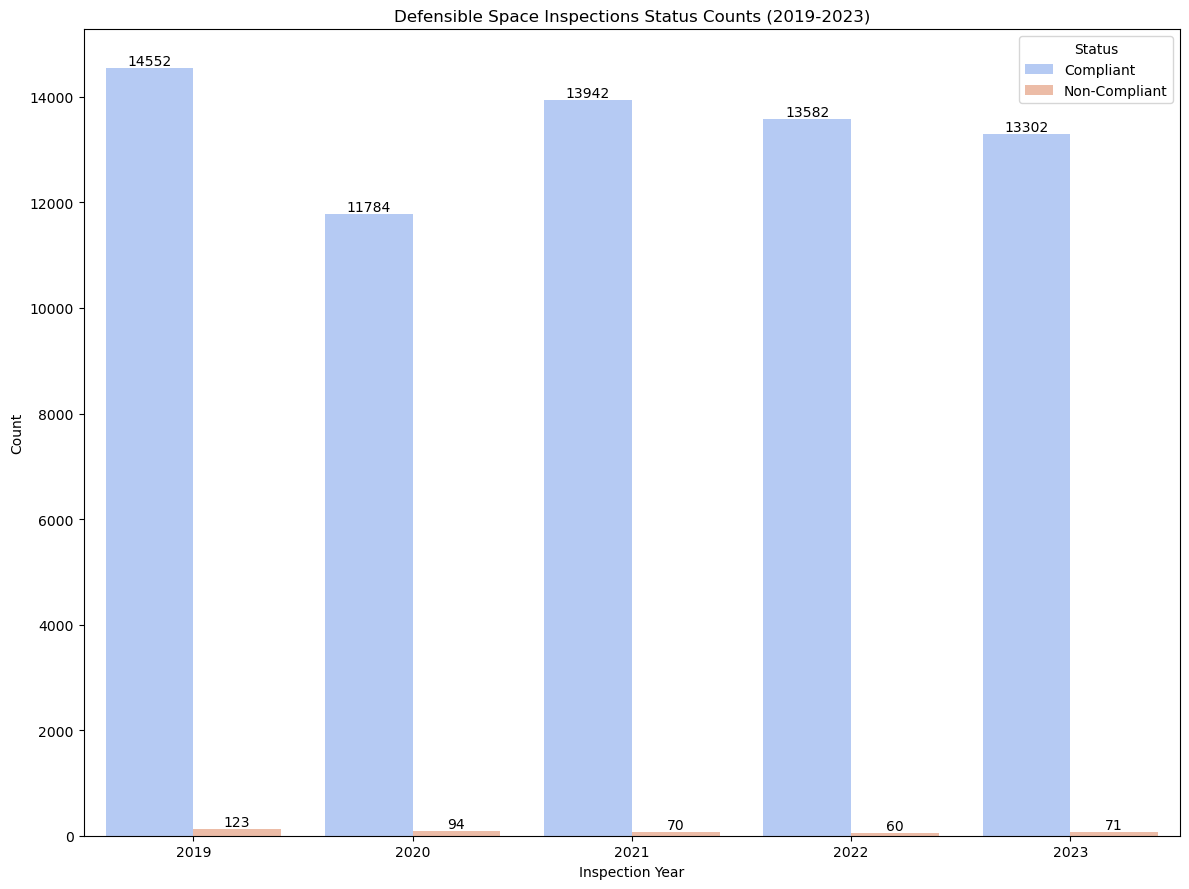

In [16]:
# First create a list to store the counts for each year
all_years_data = []

# Process each year's data
for year, df in [
    (2019, inspections_2019),
    (2020, inspections_2020),
    (2021, inspections_2021),
    (2022, inspections_2022),
    (2023, inspections_2023),
]:
    # Get status counts
    status_counts = df["status"].value_counts().reset_index()
    status_counts.columns = ["status", "count"]
    # Add year column
    status_counts["year"] = year
    # Append to our list
    all_years_data.append(status_counts)

# Combine all data
combined_data = pd.concat(all_years_data, ignore_index=True)

# Create the plot
plt.figure(figsize=(12, 9))
bars = sns.barplot(
    x="year", y="count", hue="status", data=combined_data, palette="coolwarm"
)

# Add count annotations on top of each bar
for container in bars.containers:
    bars.bar_label(container, fmt="%d", fontsize=10)

# Add labels and title
plt.title("Defensible Space Inspections Status Counts (2019-2023)")
plt.xlabel("Inspection Year")
plt.ylabel("Count")
plt.legend(title="Status")

# Show the plot
plt.tight_layout()
plt.show()

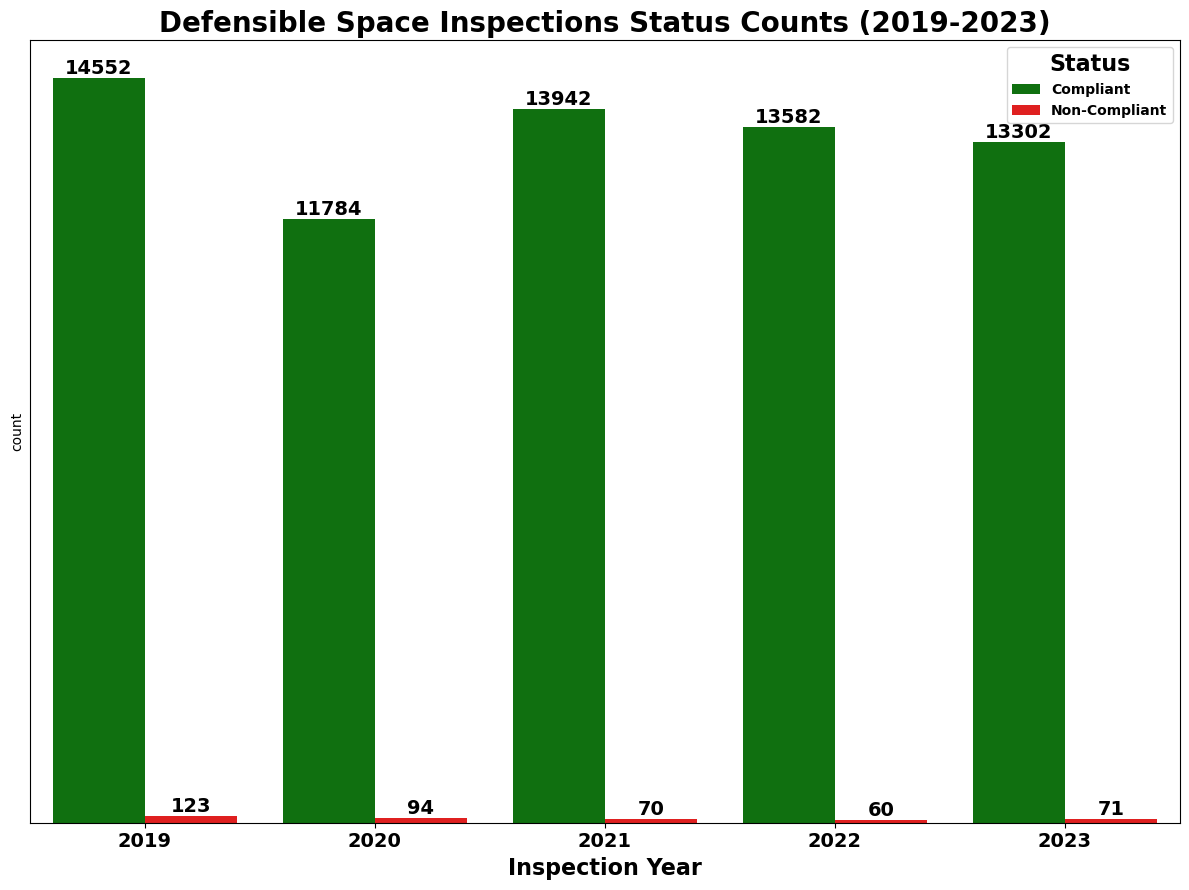

In [23]:
# First create a list to store the counts for each year
all_years_data = []

# Process each year's data
for year, df in [
    (2019, inspections_2019),
    (2020, inspections_2020),
    (2021, inspections_2021),
    (2022, inspections_2022),
    (2023, inspections_2023),
]:
    # Get status counts
    status_counts = df["status"].value_counts().reset_index()
    status_counts.columns = ["status", "count"]
    # Add year column
    status_counts["year"] = year
    # Append to our list
    all_years_data.append(status_counts)

# Combine all data
combined_data = pd.concat(all_years_data, ignore_index=True)

# Create custom color palette (green for Compliant, red for Non-Compliant)
status_colors = {
    'Compliant': 'green',
    'Non-Compliant': 'red'
}

# Create the plot
plt.figure(figsize=(12, 9))

# Create a custom palette based on status values
custom_palette = [status_colors.get(status, 'gray') for status in combined_data['status'].unique()]

bars = sns.barplot(
    x="year", y="count", hue="status", data=combined_data, palette=custom_palette
)

# Add count annotations on top of each bar with bold text
for container in bars.containers:
    bars.bar_label(container, fmt="%d", fontsize=14, fontweight='bold')

# Add labels and title with larger, bold font sizes
plt.title("Defensible Space Inspections Status Counts (2019-2023)", fontsize=20, fontweight='bold')
plt.xlabel("Inspection Year", fontsize=16, fontweight='bold')

# Remove y-axis tick marks and labels
plt.yticks([])
plt.tick_params(axis='y', which='both', left=False, labelleft=False)

# Increase x-axis tick font size and make bold
plt.xticks(fontsize=14, fontweight='bold')

# Increase legend font size and make bold
plt.legend(title="Status", fontsize=14, title_fontsize=16, 
           prop={'weight': 'bold'})

# Bold the legend title
legend = plt.gca().get_legend()
legend.get_title().set_fontweight('bold')

# Show the plot
plt.tight_layout()
plt.show()

## Plot monthly inpsections counts for all years

### Create a function that plots inspections per month for each year.

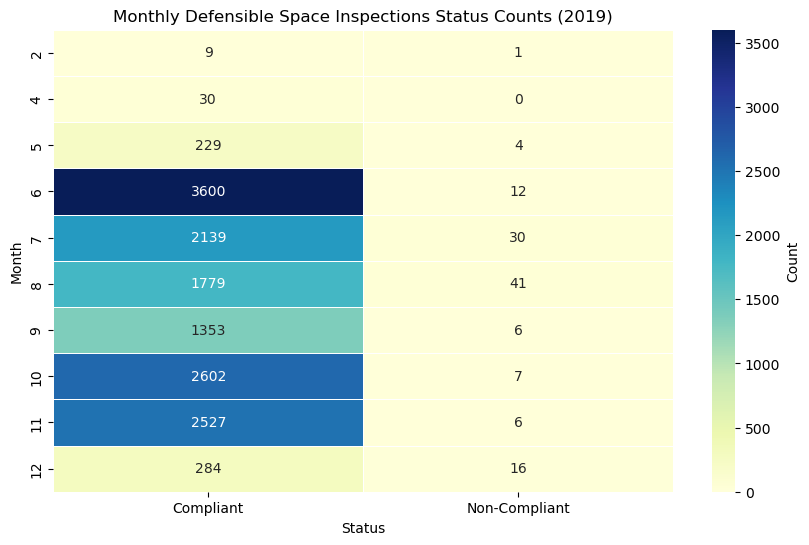

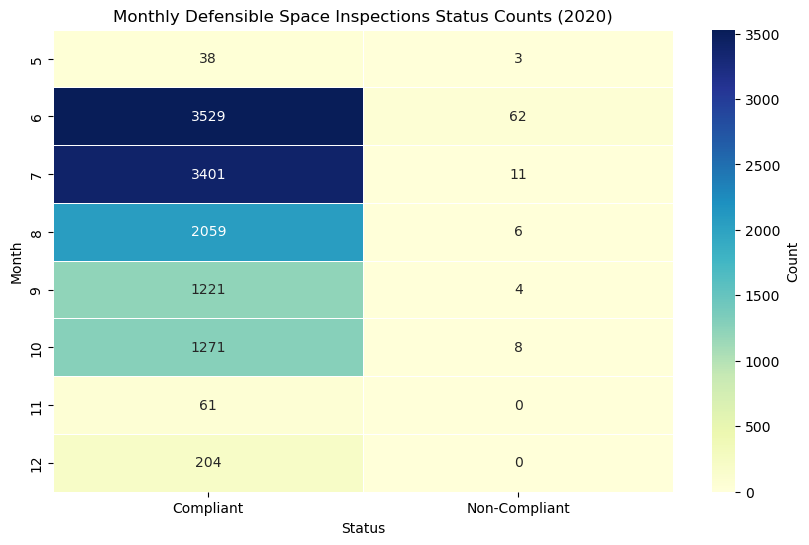

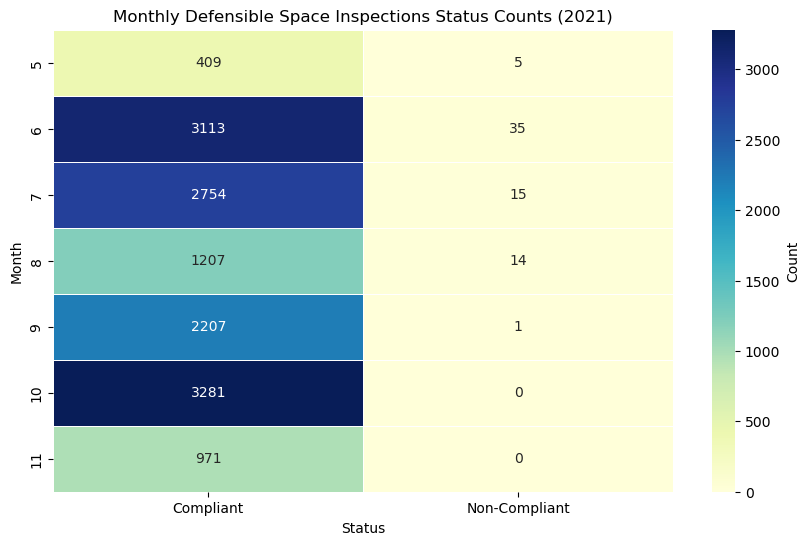

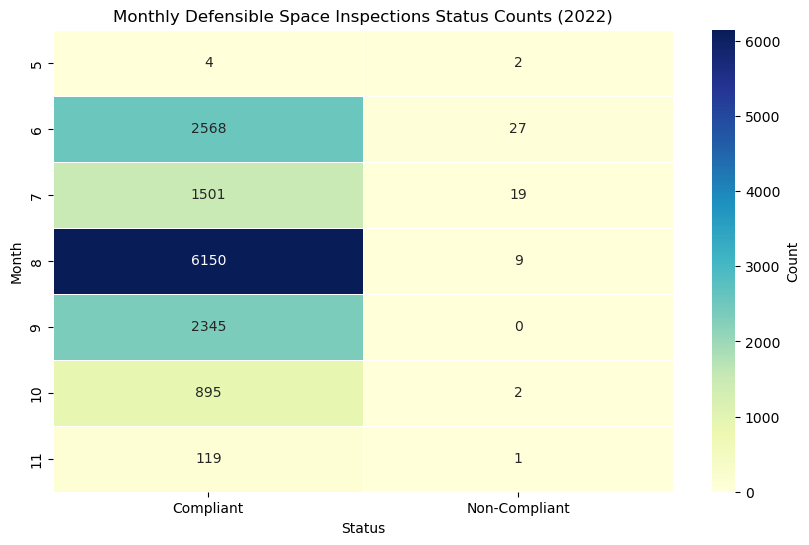

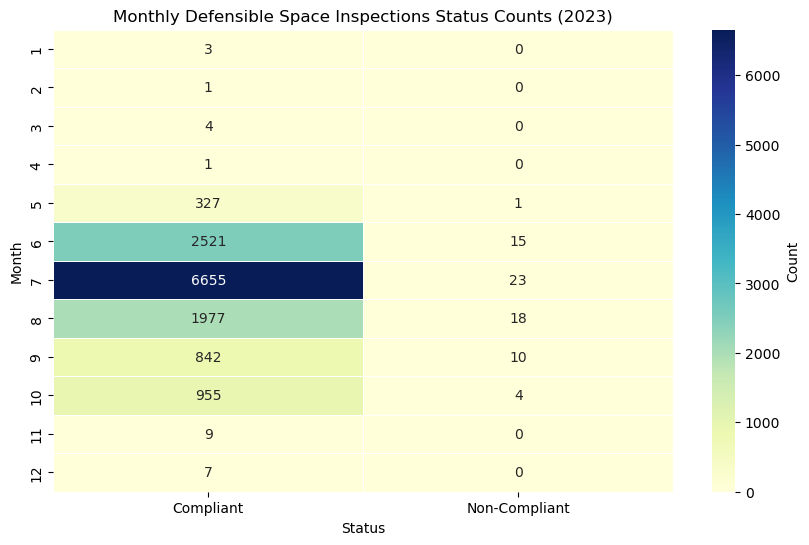

In [17]:
# Create a dictionary to hold all inspection dataframes
inspection_dataframes = {
    2019: inspections_2019,
    2020: inspections_2020,
    2021: inspections_2021,
    2022: inspections_2022,
    2023: inspections_2023,
}


# Function to count inspections per month
def count_inspections_per_month(dataframes_dict):
    """Count inspections per month for each year and create heatmaps.

    Args:
        dataframes_dict (dict): Dictionary containing dataframes for each year.

    Returns:
        dict: Dictionary with monthly counts for each year.
    """

    # Create a dictionary to hold the monthly results
    monthly_results = {}

    # Process each year's dataframe
    for year, df in dataframes_dict.items():
        # Create a month column
        df_copy = df.copy()
        df_copy["month"] = df_copy["Date"].dt.month

        # Count status by month
        inspections_monthly = (
            df_copy.groupby(["month", "status"]).size().reset_index(name="count")
        )

        # Create a pivot table
        pivot_table = inspections_monthly.pivot_table(
            index="month",
            columns="status",
            values="count",
            aggfunc="sum",
            fill_value=0,
        )

        # Store the pivot table in the results dictionary
        monthly_results[year] = pivot_table

        # Create a heatmap for each year
        plt.figure(figsize=(10, 6))
        sns.heatmap(
            pivot_table,
            annot=True,
            fmt="d",
            cmap="YlGnBu",
            cbar_kws={"label": "Count"},
            linewidths=0.5,
        )
        plt.title(f"Monthly Defensible Space Inspections Status Counts ({year})")
        plt.xlabel("Status")
        plt.ylabel("Month")
        plt.show()

    return monthly_results


# Call the function
monthly_inspection_counts = count_inspections_per_month(inspection_dataframes)


### Create a single plot showing heatmaps for all years

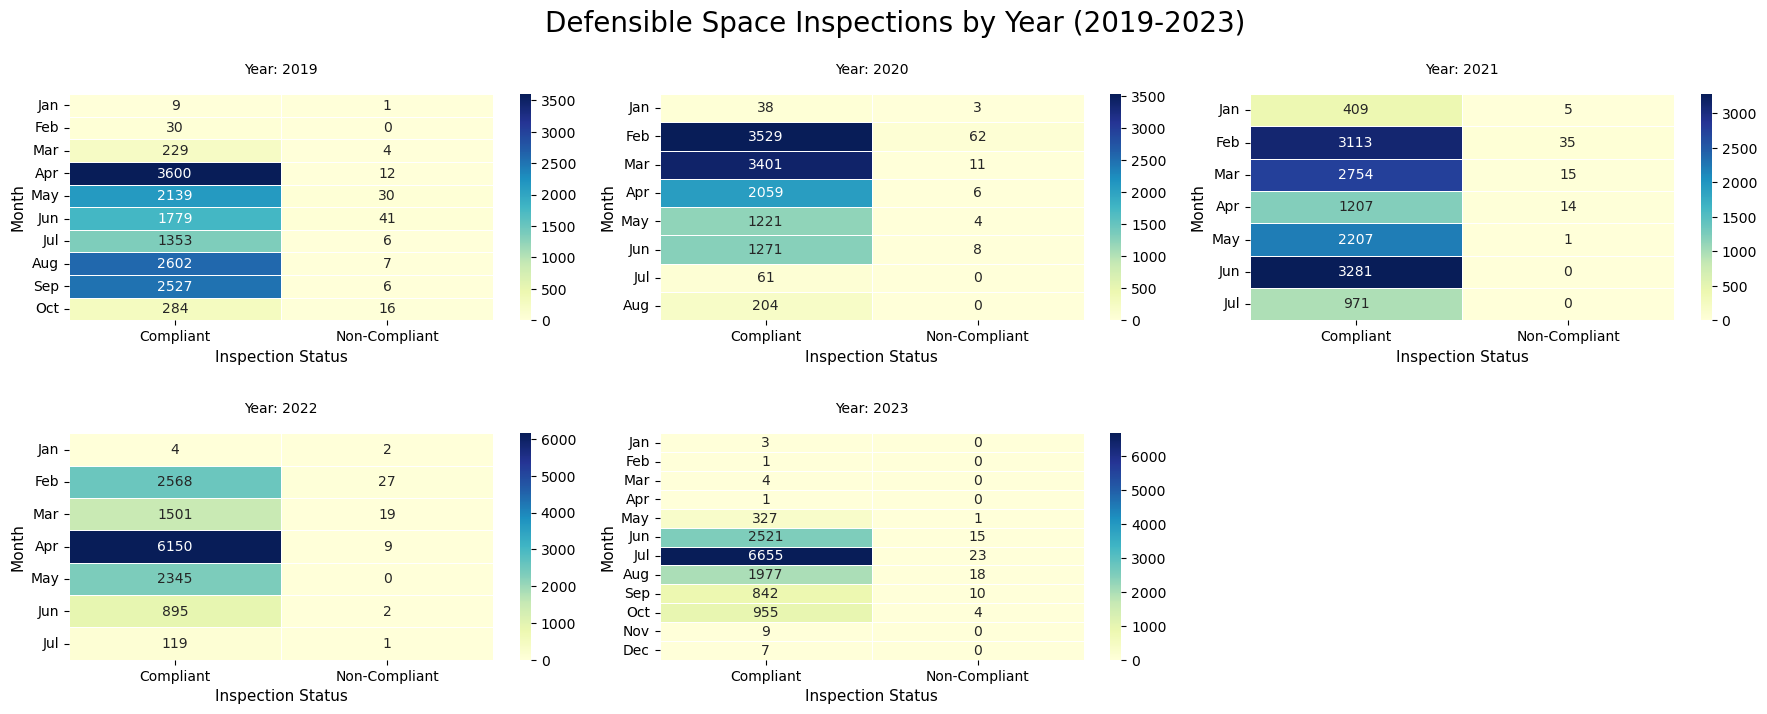

In [18]:
def create_facet_heatmaps_seaborn(dataframes_dict):
    # Prepare a list to hold processed data for all years
    all_years_data = []

    # Process each year's dataframe
    for year, df in dataframes_dict.items():
        # Create month and year columns
        df_copy = df.copy()
        df_copy["month"] = df_copy["Date"].dt.month
        df_copy["year"] = year

        # Count status by month and year
        inspections_monthly = (
            df_copy.groupby(["year", "month", "status"])
            .size()
            .reset_index(name="count")
        )

        all_years_data.append(inspections_monthly)

    # Combine all data
    combined_data = pd.concat(all_years_data)

    # Create a pivot table for each year
    pivot_data = []

    for year, year_data in combined_data.groupby("year"):
        # Create pivot table for this year
        year_pivot = year_data.pivot_table(
            index="month", columns="status", values="count", aggfunc="sum", fill_value=0
        ).reset_index()

        # Melt to long format and create rows for each month-status combination
        melted = pd.melt(
            year_pivot, id_vars=["month"], var_name="status", value_name="count"
        )

        # Add year back in
        melted["year"] = year

        pivot_data.append(melted)

    # Combine all pivoted data
    all_pivot_data = pd.concat(pivot_data)

    # Create facet grid
    g = sns.FacetGrid(
        all_pivot_data,
        col="year",
        col_wrap=3,
        height=5,  # Increased height
        aspect=1.2,
        despine=True,
        sharex=False,
        sharey=False,
    )

    # Define a function to create a heatmap for each facet
    def plot_heatmap(data, color, **kwargs):
        # Pivot the data for this particular facet
        pivot = data.pivot(index="month", columns="status", values="count")

        # Create heatmap on the current axes
        ax = plt.gca()
        sns.heatmap(
            pivot, annot=True, fmt="d", cmap="YlGnBu", cbar=True, ax=ax, linewidths=0.5
        )

        # Add month labels (convert month numbers to month names)
        month_names = [
            "Jan",
            "Feb",
            "Mar",
            "Apr",
            "May",
            "Jun",
            "Jul",
            "Aug",
            "Sep",
            "Oct",
            "Nov",
            "Dec",
        ]
        month_positions = range(len(pivot.index))
        ax.set_yticks(np.array(month_positions) + 0.5)
        ax.set_yticklabels(month_names[: len(pivot.index)], rotation=0)

        # Add axis labels for each individual plot
        ax.set_xlabel("Inspection Status", fontsize=11)
        ax.set_ylabel("Month", fontsize=11)

    # Map the heatmap function to each facet
    g.map_dataframe(plot_heatmap)

    g.set_titles("Year: {col_name}", fontsize=16, pad=15)
    g.fig.suptitle(
        "Defensible Space Inspections by Year (2019-2023)", y=1.05, fontsize=20
    )
    g.fig.subplots_adjust(
        bottom=0.4,
        hspace=0.5,
    )
    plt.show()

    return all_pivot_data


# Call the function
facet_heatmaps = create_facet_heatmaps_seaborn(inspection_dataframes)


## Create unique ID for each inspection

In [19]:
# Function to read in inspections data for 2019-2023
def import_inspections_data(year):
    """
    Function to read in inspections data for a given year and convert to Albers CRS.
    """
    inspections = os.path.join(
        config.cleaned_inspections_dir, f"inspections_{year}.geojson"
    )
    inspections = gpd.read_file(inspections).to_crs(config.albers_crs)
    return inspections


# Read in inspection data for 2019-2023 as separate dataframes
inspections_dict = {}
for year in range(2019, 2024):
    inspections_dict[year] = import_inspections_data(year)

In [20]:
def assign_unique_ids(start_year, end_year):
    """
    Load inspections for all years, assign unique IDs, and split back into yearly files.

    Args:
        start_year (int): First year to import
        end_year (int): Last year to import

    Returns:
        dict: Dictionary with year as key and GeoDataFrame with unique IDs as value
    """
    # Step 1: Import data for each year into a dictionary
    inspections_dict = {}
    for year in range(start_year, end_year + 1):
        df = import_inspections_data(year)
        # Create a year column if it doesn't exist
        if "year" not in df.columns:
            df["year"] = year
        inspections_dict[year] = df

    # Step 2: Combine all years into one GeoDataFrame for ID assignment
    if inspections_dict:  # Check if dictionary has entries
        all_inspections = pd.concat(
            inspections_dict.values(), axis=0, ignore_index=True
        )

        # Step 3: Add a unique inspection ID to the combined dataset
        all_inspections["inspection_id"] = np.arange(1, len(all_inspections) + 1)

        # Step 4: Split back into yearly files while preserving the unique IDs
        yearly_inspections_with_ids = {}
        for year in range(start_year, end_year + 1):
            yearly_data = all_inspections[all_inspections["year"] == year].copy()
            yearly_inspections_with_ids[year] = yearly_data

        return yearly_inspections_with_ids


# Generate the inspections with unique IDs for all years
inspections_with_ids = assign_unique_ids(2019, 2023)

# Save each year as a separate file with unique IDs preserved
for year, df in inspections_with_ids.items():
    # Save to file (you can customize the path/format as needed)
    output_path = os.path.join(
        config.cleaned_inspections_dir, f"inspections_{year}.geojson"
    )
    df.to_file(output_path, driver="GeoJSON")

/tmp/ipykernel_1760810/3521570876.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_inspections = pd.concat(
/Users/rubinstein/.conda/envs/wildfire_prep/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


In [21]:
# Function to verify the presence of the inspection_id column
def verify_inspection_id_column(start_year, end_year):
    for year in range(start_year, end_year + 1):
        # Path to the saved file
        file_path = os.path.join(config.cleaned_inspections_dir, f"inspections_{year}.geojson")

        # Load the file
        try:
            gdf = gpd.read_file(file_path)

            # Check if inspection_id column exists
            if "inspection_id" in gdf.columns:
                print(
                    f"Year {year}: ✓ inspection_id column found with {len(gdf)} records"
                )
                # Display first few rows to see the IDs
                print(f"Sample IDs: {gdf['inspection_id'].head(3).tolist()}")
            else:
                print(f"Year {year}: ✗ inspection_id column NOT found!")
        except Exception as e:
            print(f"Year {year}: Error loading file - {str(e)}")

        print("-" * 50)  # Separator


# Run the verification function on the same year range
verify_inspection_id_column(2019, 2023)

Year 2019: ✓ inspection_id column found with 14675 records
Sample IDs: [1, 2, 3]
--------------------------------------------------
Year 2020: ✓ inspection_id column found with 11878 records
Sample IDs: [14676, 14677, 14678]
--------------------------------------------------
Year 2021: ✓ inspection_id column found with 14012 records
Sample IDs: [26554, 26555, 26556]
--------------------------------------------------
Year 2022: ✓ inspection_id column found with 13642 records
Sample IDs: [40566, 40567, 40568]
--------------------------------------------------
Year 2023: ✓ inspection_id column found with 13373 records
Sample IDs: [54208, 54209, 54210]
--------------------------------------------------
